# 99 - PyCon JP 大規模データでの ITQ-LSH 再評価

NB91〜98 で得られた知見を、PyCon JP の大規模データ（約75K faces / 約20K images）で再評価する。

## 目的
- NB93〜97 では terada (20クエリ) のみで評価 → **クラスタベースの多様なクエリで汎用性を検証**
- cluster_id が付与された複数クラスタ（23クラスタ, 3人以上）をクエリとして使用
- 同一クラスタ内の検索精度（Recall, MRR）を「人物再発見」タスクとして測定

## 評価項目
1. データ概要と空間特性の確認
2. ITQ カスケード検索の Recall@K（候補数・ビット数スイープ）
3. Pivot 戦略の候補削減効果
4. 速度ベンチマーク
5. 総合比較と NB98 の推奨構成の妥当性検証

## 注意事項
- 個人を特定する情報（顔画像、face_id、ファイル名等）は表示しない
- 統計値と集計結果のみを扱う

In [1]:
import sys
sys.path.insert(0, "../src")

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from pathlib import Path
from collections import Counter

from image_vector_poc.search.lsh.itq import ITQLSH
from image_vector_poc.search.lsh.cascade import CascadeSearcher

DB_PATH = Path("../data/images.duckdb")
MODEL_DIR = Path("../data/itq_models")

conn = duckdb.connect(str(DB_PATH), read_only=True)
conn.execute("LOAD vss;")

# 全顔埋め込みとメタデータを取得
rows = conn.execute("""
    SELECT f.face_id, f.embedding, f.cluster_id
    FROM face_detections f
    WHERE f.model_name = 'insightface/buffalo_l'
    ORDER BY f.face_id
""").fetchall()

face_ids = [r[0] for r in rows]
embeddings = np.array([[float(x) for x in r[1]] for r in rows], dtype=np.float32)
cluster_ids = [r[2] for r in rows]

# L2正規化
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
embeddings = embeddings / norms

# face_id -> index マッピング
fid_to_idx = {fid: i for i, fid in enumerate(face_ids)}

print(f"Total faces: {len(embeddings):,}")
print(f"Embedding dim: {embeddings.shape[1]}")
print(f"Faces with cluster_id: {sum(1 for c in cluster_ids if c is not None)}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Total faces: 75,162
Embedding dim: 512
Faces with cluster_id: 236


## 1. データ概要とクエリ構築

cluster_id >= 3 メンバーのクラスタを対象に、各クラスタから1つをクエリ、残りを正解（同一人物）として使用する。
NB93 では terada 20件のみだったが、ここでは複数人物での汎用性を検証する。

In [2]:
# クラスタ別の顔インデックスを収集
cluster_members = {}
for i, cid in enumerate(cluster_ids):
    if cid is not None:
        cluster_members.setdefault(cid, []).append(i)

# 3メンバー以上のクラスタを対象
MIN_CLUSTER_SIZE = 3
valid_clusters = {cid: members for cid, members in cluster_members.items() if len(members) >= MIN_CLUSTER_SIZE}

print(f"全クラスタ数: {len(cluster_members)}")
print(f"3人以上のクラスタ数: {len(valid_clusters)}")
print(f"\nクラスタサイズ分布:")

size_dist = Counter(len(m) for m in valid_clusters.values())
for size in sorted(size_dist.keys()):
    print(f"  {size}人: {size_dist[size]} クラスタ")

total_query_faces = sum(len(m) for m in valid_clusters.values())
print(f"\n対象顔数合計: {total_query_faces}")

# 各クラスタからクエリを構築
# 各メンバーを順にクエリとし、同一クラスタの他メンバーを正解とする
queries = []  # (query_idx, cluster_id, gt_indices)
for cid in sorted(valid_clusters.keys()):
    members = valid_clusters[cid]
    for qi, q_idx in enumerate(members):
        gt_indices = [m for m in members if m != q_idx]
        queries.append({
            "query_idx": q_idx,
            "cluster_id": cid,
            "gt_indices": gt_indices,
        })

print(f"\n総クエリ数: {len(queries)} (各メンバーを順にクエリとして使用)")

全クラスタ数: 60
3人以上のクラスタ数: 23

クラスタサイズ分布:
  3人: 7 クラスタ
  4人: 5 クラスタ
  5人: 1 クラスタ
  6人: 4 クラスタ
  7人: 2 クラスタ
  8人: 2 クラスタ
  20人: 1 クラスタ
  42人: 1 クラスタ

対象顔数合計: 162

総クエリ数: 162 (各メンバーを順にクエリとして使用)


## 2. Brute-force ベースライン（Ground Truth）

各クエリに対して、brute-force で Top-K を計算し、Ground Truth とする。
また、クラスタ内の正解がTop-K にどれだけ含まれるか（Cluster Recall）も同時に計算する。

In [3]:
TOP_K_VALUES = [1, 5, 10, 20, 50]
MAX_K = max(TOP_K_VALUES)

# Brute-force Ground Truth
ground_truth = {}  # query index in queries list -> {indices, scores}
for qi, q in enumerate(queries):
    q_emb = embeddings[q["query_idx"]]
    sims = embeddings @ q_emb
    sims[q["query_idx"]] = -1  # 自分自身を除外
    top_indices = np.argsort(-sims)[:MAX_K]
    top_scores = sims[top_indices]
    ground_truth[qi] = {
        "indices": top_indices,
        "scores": top_scores,
    }

print(f"Ground truth computed for {len(ground_truth)} queries, top-{MAX_K} each")

# クラスタベースの Recall: 同一クラスタの正解がBF Top-K に含まれる割合
cluster_recall_bf = {}
for k in TOP_K_VALUES:
    recalls = []
    for qi, q in enumerate(queries):
        gt_set = set(ground_truth[qi]["indices"][:k])
        cluster_gt = set(q["gt_indices"])
        found = len(gt_set & cluster_gt)
        recalls.append(found / len(cluster_gt) if cluster_gt else 0.0)
    cluster_recall_bf[k] = np.mean(recalls)

print(f"\nBrute-force Cluster Recall (同一クラスタメンバーの発見率):")
for k, r in cluster_recall_bf.items():
    print(f"  Top-{k}: {r:.4f}")

# クラスタ別の同一人物類似度統計
print(f"\nクラスタ別の同一人物間コサイン類似度:")
for cid in sorted(valid_clusters.keys())[:10]:
    members = valid_clusters[cid]
    sims_intra = []
    for i in range(len(members)):
        for j in range(i+1, len(members)):
            s = float(embeddings[members[i]] @ embeddings[members[j]])
            sims_intra.append(s)
    print(f"  Cluster {cid:2d} ({len(members):2d}人): mean={np.mean(sims_intra):.4f}, min={np.min(sims_intra):.4f}, max={np.max(sims_intra):.4f}")
print(f"  ... (以下省略)")

Ground truth computed for 162 queries, top-50 each

Brute-force Cluster Recall (同一クラスタメンバーの発見率):
  Top-1: 0.1199
  Top-5: 0.3693
  Top-10: 0.4472
  Top-20: 0.5317
  Top-50: 0.6135

クラスタ別の同一人物間コサイン類似度:
  Cluster  0 (20人): mean=0.7048, min=0.5639, max=0.8738
  Cluster  1 (42人): mean=0.4525, min=0.1032, max=0.8440
  Cluster  2 ( 6人): mean=0.6218, min=0.5337, max=0.7358
  Cluster  3 ( 6人): mean=0.6862, min=0.6140, max=0.7556
  Cluster  4 ( 6人): mean=0.5809, min=0.4355, max=0.6704
  Cluster  6 ( 7人): mean=0.6225, min=0.4938, max=0.7335
  Cluster  8 ( 3人): mean=0.7686, min=0.7330, max=0.8373
  Cluster 12 ( 4人): mean=0.7206, min=0.6727, max=0.8224
  Cluster 18 ( 8人): mean=0.6740, min=0.5395, max=0.9058
  Cluster 21 ( 4人): mean=0.6283, min=0.5307, max=0.7401
  ... (以下省略)


## 3. HNSW 検索 (DuckDB vss)

In [4]:
# HNSW 検索
hnsw_results = {}  # qi -> [indices]
hnsw_times = []

for qi, q in enumerate(queries):
    q_emb = embeddings[q["query_idx"]]
    q_list = [float(x) for x in q_emb]
    t0 = time.perf_counter()
    result = conn.execute(f"""
        SELECT f.face_id
        FROM face_detections f
        WHERE f.model_name = 'insightface/buffalo_l'
        ORDER BY array_cosine_distance(f.embedding, ?::FLOAT[512])
        LIMIT {MAX_K + 1}
    """, [q_list]).fetchall()
    elapsed = time.perf_counter() - t0
    hnsw_times.append(elapsed)
    
    result_fids = [r[0] for r in result]
    # 自分自身を除外
    q_fid = face_ids[q["query_idx"]]
    result_indices = [fid_to_idx[fid] for fid in result_fids if fid != q_fid][:MAX_K]
    hnsw_results[qi] = result_indices

print(f"HNSW search done: {len(hnsw_results)} queries")
print(f"Mean latency: {np.mean(hnsw_times)*1000:.1f} ms")
print(f"P95 latency: {np.percentile(hnsw_times, 95)*1000:.1f} ms")

HNSW search done: 162 queries
Mean latency: 3.3 ms
P95 latency: 2.7 ms


## 4. ITQ-LSH カスケード検索

NB92 で学習済みの ITQ モデル（64/96/128/256bit）を使い、候補数スイープで Recall@K を評価。

In [5]:
CANDIDATE_SIZES = [100, 200, 500, 1000, 2000, 5000]
BIT_COUNTS = sorted(set(
    int(p.stem.split("_")[-1].replace("bit", ""))
    for p in MODEL_DIR.glob("itq_arcface_*bit.pkl")
))
print(f"Testing bit counts: {BIT_COUNTS}")

cascade_results = {}  # (n_bits, candidates) -> {qi: [indices]}

for n_bits in BIT_COUNTS:
    model_path = MODEL_DIR / f"itq_arcface_{n_bits}bit.pkl"
    itq = ITQLSH.load(str(model_path))
    searcher = CascadeSearcher(itq)
    searcher.build_index(embeddings, metadata=list(range(len(embeddings))), show_progress=False)
    
    for candidates in CANDIDATE_SIZES:
        key = (n_bits, candidates)
        cascade_results[key] = {}
        
        for qi, q in enumerate(queries):
            q_emb = embeddings[q["query_idx"]]
            result = searcher.search(q_emb, candidates=candidates, top_k=MAX_K)
            result_indices = [m for m in result["metadata"] if m != q["query_idx"]][:MAX_K]
            cascade_results[key][qi] = result_indices
    
    print(f"  {n_bits}bit: done")

print(f"\nTotal configurations: {len(cascade_results)}")

Testing bit counts: [64, 96, 128, 256]


  64bit: done


  96bit: done


  128bit: done


  256bit: done

Total configurations: 24


## 5. 精度メトリクス計算

2つの観点で評価:
1. **BF-Recall@K**: Brute-force Top-K との一致率（NB93 と同じ基準）
2. **Cluster Recall@K**: 同一クラスタメンバーがTop-K に含まれる割合（人物再発見タスク）

In [6]:
def compute_bf_recall(result_indices, gt_indices, k):
    """BF Top-K との一致率"""
    gt_set = set(gt_indices[:k])
    ret_set = set(result_indices[:k])
    return len(gt_set & ret_set) / len(gt_set) if gt_set else 0.0

def compute_cluster_recall(result_indices, cluster_gt_indices, k):
    """同一クラスタメンバーの発見率"""
    ret_set = set(result_indices[:k])
    gt_set = set(cluster_gt_indices)
    return len(ret_set & gt_set) / len(gt_set) if gt_set else 0.0

def compute_mrr(result_indices, gt_first_index, k=10):
    """MRR: GT top-1 が検索結果のどの位置にあるか"""
    for rank, idx in enumerate(result_indices[:k], 1):
        if idx == gt_first_index:
            return 1.0 / rank
    return 0.0

def evaluate_method(results_dict, ground_truth, queries, k_values):
    """全クエリでのメトリクス集計"""
    metrics = {}
    for k in k_values:
        bf_recalls = []
        cluster_recalls = []
        mrrs = []
        for qi in range(len(queries)):
            gt_indices = ground_truth[qi]["indices"]
            ret_indices = results_dict[qi]
            bf_recalls.append(compute_bf_recall(ret_indices, gt_indices, k))
            cluster_recalls.append(compute_cluster_recall(ret_indices, queries[qi]["gt_indices"], k))
            if k == 10:
                mrrs.append(compute_mrr(ret_indices, gt_indices[0], k))
        metrics[f"BF-Recall@{k}"] = np.mean(bf_recalls)
        metrics[f"Cluster-Recall@{k}"] = np.mean(cluster_recalls)
        if k == 10:
            metrics["MRR@10"] = np.mean(mrrs)
    return metrics

# HNSW メトリクス
hnsw_metrics = evaluate_method(hnsw_results, ground_truth, queries, TOP_K_VALUES)
print("=== HNSW ===")
for k, v in hnsw_metrics.items():
    print(f"  {k}: {v:.4f}")

# ITQ-LSH カスケードのメトリクス
print("\n=== ITQ-LSH Cascade (BF-Recall@10 / Cluster-Recall@10 / MRR@10) ===")
cascade_metrics = {}
for (n_bits, candidates), results in sorted(cascade_results.items()):
    m = evaluate_method(results, ground_truth, queries, TOP_K_VALUES)
    cascade_metrics[(n_bits, candidates)] = m
    print(f"  {n_bits:3d}bit, cand={candidates:5d}: BF-R@10={m['BF-Recall@10']:.4f}, Cluster-R@10={m['Cluster-Recall@10']:.4f}, MRR@10={m['MRR@10']:.4f}")

=== HNSW ===
  BF-Recall@1: 0.9877
  Cluster-Recall@1: 0.1191
  BF-Recall@5: 0.9864
  Cluster-Recall@5: 0.3649
  BF-Recall@10: 0.9673
  Cluster-Recall@10: 0.4410
  MRR@10: 0.9907
  BF-Recall@20: 0.9364
  Cluster-Recall@20: 0.5256
  BF-Recall@50: 0.8902
  Cluster-Recall@50: 0.6074

=== ITQ-LSH Cascade (BF-Recall@10 / Cluster-Recall@10 / MRR@10) ===
   64bit, cand=  100: BF-R@10=0.6975, Cluster-R@10=0.3960, MRR@10=0.8765
   64bit, cand=  200: BF-R@10=0.8080, Cluster-R@10=0.4252, MRR@10=0.9691
   64bit, cand=  500: BF-R@10=0.8716, Cluster-R@10=0.4398, MRR@10=0.9907
   64bit, cand= 1000: BF-R@10=0.9111, Cluster-R@10=0.4458, MRR@10=0.9969
   64bit, cand= 2000: BF-R@10=0.9309, Cluster-R@10=0.4472, MRR@10=0.9969
   64bit, cand= 5000: BF-R@10=0.9488, Cluster-R@10=0.4472, MRR@10=1.0000
   96bit, cand=  100: BF-R@10=0.7747, Cluster-R@10=0.4338, MRR@10=0.8981
   96bit, cand=  200: BF-R@10=0.8562, Cluster-R@10=0.4462, MRR@10=0.9784
   96bit, cand=  500: BF-R@10=0.9049, Cluster-R@10=0.4472, MRR@10=

## 6. 可視化

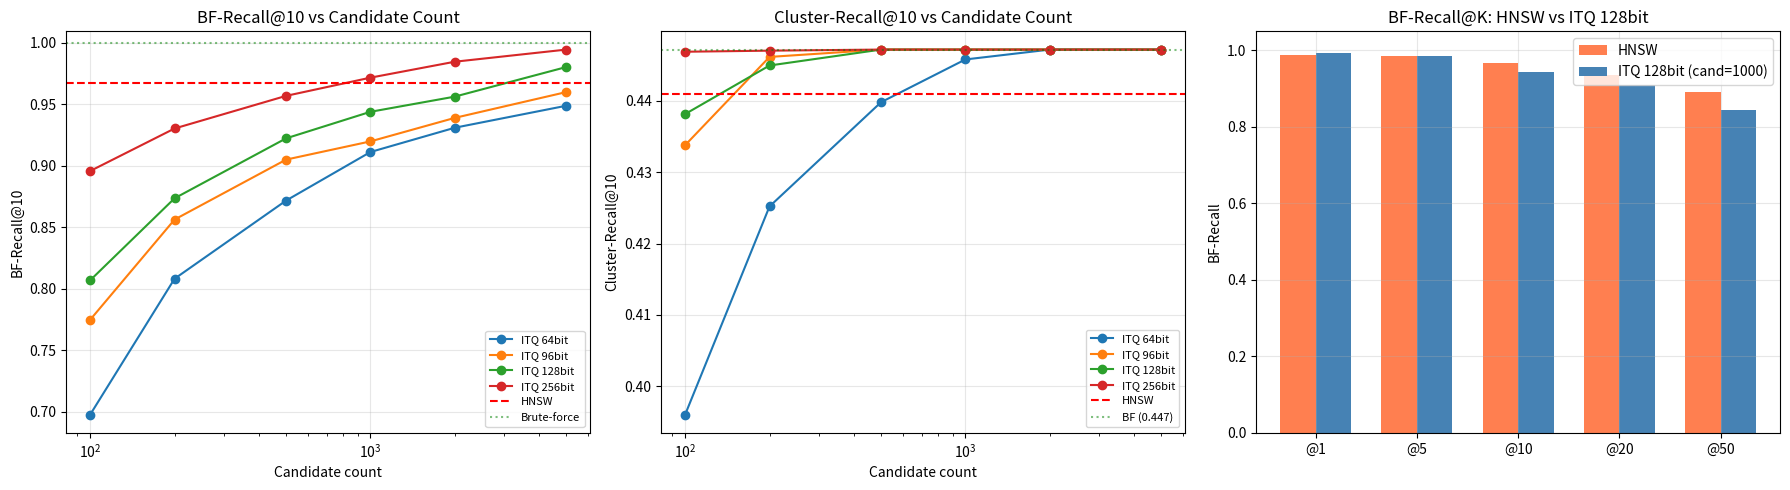

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) BF-Recall@10 vs 候補数（ビット数別）
for n_bits in BIT_COUNTS:
    recalls = []
    cands = []
    for candidates in CANDIDATE_SIZES:
        key = (n_bits, candidates)
        if key in cascade_metrics:
            recalls.append(cascade_metrics[key]["BF-Recall@10"])
            cands.append(candidates)
    if recalls:
        axes[0].plot(cands, recalls, "o-", label=f"ITQ {n_bits}bit")

axes[0].axhline(y=hnsw_metrics["BF-Recall@10"], color="red", linestyle="--", label="HNSW")
axes[0].axhline(y=1.0, color="green", linestyle=":", alpha=0.5, label="Brute-force")
axes[0].set_xlabel("Candidate count")
axes[0].set_ylabel("BF-Recall@10")
axes[0].set_title("BF-Recall@10 vs Candidate Count")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].set_xscale("log")

# (b) Cluster-Recall@10 vs 候補数
for n_bits in BIT_COUNTS:
    recalls = []
    cands = []
    for candidates in CANDIDATE_SIZES:
        key = (n_bits, candidates)
        if key in cascade_metrics:
            recalls.append(cascade_metrics[key]["Cluster-Recall@10"])
            cands.append(candidates)
    if recalls:
        axes[1].plot(cands, recalls, "o-", label=f"ITQ {n_bits}bit")

axes[1].axhline(y=hnsw_metrics["Cluster-Recall@10"], color="red", linestyle="--", label="HNSW")
cr_bf_10 = cluster_recall_bf[10]
axes[1].axhline(y=cr_bf_10, color="green", linestyle=":", alpha=0.5, label=f"BF ({cr_bf_10:.3f})")
axes[1].set_xlabel("Candidate count")
axes[1].set_ylabel("Cluster-Recall@10")
axes[1].set_title("Cluster-Recall@10 vs Candidate Count")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].set_xscale("log")

# (c) BF-Recall@K 比較（128bit, candidates=1000）
key_128_1000 = (128, 1000)
if key_128_1000 in cascade_metrics:
    k_values_plot = [k for k in TOP_K_VALUES]
    hnsw_recalls = [hnsw_metrics.get(f"BF-Recall@{k}", 0) for k in k_values_plot]
    itq_recalls = [cascade_metrics[key_128_1000].get(f"BF-Recall@{k}", 0) for k in k_values_plot]
    
    x = np.arange(len(k_values_plot))
    w = 0.35
    axes[2].bar(x - w/2, hnsw_recalls, w, label="HNSW", color="coral")
    axes[2].bar(x + w/2, itq_recalls, w, label="ITQ 128bit (cand=1000)", color="steelblue")
    axes[2].set_xticks(x)
    axes[2].set_xticklabels([f"@{k}" for k in k_values_plot])
    axes[2].set_ylabel("BF-Recall")
    axes[2].set_title("BF-Recall@K: HNSW vs ITQ 128bit")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    axes[2].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

## 7. Pivot 戦略の評価

NB96 と同じ手法で、多様なクエリでの Pivot フィルタリング効果を検証する。

In [8]:
# ITQ 128bit ハッシュを取得
itq_128 = ITQLSH.load(str(MODEL_DIR / "itq_arcface_128bit.pkl"))
hashes = itq_128.transform(embeddings)

def hamming_dist_batch(h1, h_all):
    """h1: (n_bits,), h_all: (n, n_bits) -> (n,)"""
    return np.sum(h1 != h_all, axis=1)

def select_pivots_farthest(hashes, n_pivots, seed=42):
    rng = np.random.default_rng(seed)
    selected = [rng.integers(len(hashes))]
    for _ in range(n_pivots - 1):
        min_dists = np.full(len(hashes), np.inf)
        for s in selected:
            dists = hamming_dist_batch(hashes[s], hashes)
            min_dists = np.minimum(min_dists, dists)
        selected.append(np.argmax(min_dists))
    return np.array(selected)

def pivot_filter(query_hash, hashes, pivot_indices, pivot_distances, threshold):
    """三角不等式による枝刈り"""
    q_pivot_dists = np.array([np.sum(query_hash != hashes[p]) for p in pivot_indices])
    keep = np.ones(len(hashes), dtype=bool)
    for p_idx, p in enumerate(pivot_indices):
        diff = np.abs(q_pivot_dists[p_idx] - pivot_distances[:, p_idx])
        keep &= (diff <= threshold)
    return np.where(keep)[0]

# Pivot 評価 (farthest-first のみ)
PIVOT_COUNTS = [4, 8, 16]
THRESHOLDS = [15, 20, 25, 30, 40]
N_TOTAL = len(embeddings)

pivot_results = []
for n_pivots in PIVOT_COUNTS:
    pivot_idx = select_pivots_farthest(hashes, n_pivots, seed=42)
    pivot_dists = np.zeros((N_TOTAL, n_pivots), dtype=np.int32)
    for p_i, p in enumerate(pivot_idx):
        pivot_dists[:, p_i] = hamming_dist_batch(hashes[p], hashes)
    
    for threshold in THRESHOLDS:
        candidate_sizes = []
        bf_recalls = []
        cluster_recalls = []
        
        for qi, q in enumerate(queries):
            q_idx = q["query_idx"]
            candidates = pivot_filter(hashes[q_idx], hashes, pivot_idx, pivot_dists, threshold)
            candidates = candidates[candidates != q_idx]  # 自分自身を除外
            candidate_sizes.append(len(candidates))
            
            # Pivot 候補内で brute-force → Top-K
            if len(candidates) > 0:
                q_emb = embeddings[q_idx]
                cand_sims = embeddings[candidates] @ q_emb
                top_local = np.argsort(-cand_sims)[:MAX_K]
                result_indices = candidates[top_local].tolist()
            else:
                result_indices = []
            
            gt_top = ground_truth[qi]["indices"]
            bf_recalls.append(compute_bf_recall(result_indices, gt_top, 10))
            cluster_recalls.append(compute_cluster_recall(result_indices, q["gt_indices"], 10))
        
        pivot_results.append({
            "n_pivots": n_pivots,
            "threshold": threshold,
            "mean_candidates": np.mean(candidate_sizes),
            "reduction_pct": (1 - np.mean(candidate_sizes) / N_TOTAL) * 100,
            "BF-Recall@10": np.mean(bf_recalls),
            "Cluster-Recall@10": np.mean(cluster_recalls),
        })
    print(f"  p={n_pivots}: done")

pivot_df = pd.DataFrame(pivot_results)
print(f"\n{'Pivots':>6} | {'Thresh':>6} | {'Candidates':>10} | {'Reduction':>9} | {'BF-R@10':>8} | {'Clust-R@10':>10}")
print("-" * 65)
for _, row in pivot_df.iterrows():
    print(f"{int(row['n_pivots']):6d} | {int(row['threshold']):6d} | {row['mean_candidates']:10.0f} | {row['reduction_pct']:8.1f}% | {row['BF-Recall@10']:8.4f} | {row['Cluster-Recall@10']:10.4f}")

  p=4: done


  p=8: done


  p=16: done

Pivots | Thresh | Candidates | Reduction |  BF-R@10 | Clust-R@10
-----------------------------------------------------------------
     4 |     15 |      45332 |     39.7% |   0.9642 |     0.4348
     4 |     20 |      61651 |     18.0% |   0.9963 |     0.4472
     4 |     25 |      69662 |      7.3% |   0.9981 |     0.4472
     4 |     30 |      73240 |      2.6% |   0.9994 |     0.4472
     4 |     40 |      75073 |      0.1% |   1.0000 |     0.4472
     8 |     15 |      33674 |     55.2% |   0.9438 |     0.4329
     8 |     20 |      56837 |     24.4% |   0.9944 |     0.4472
     8 |     25 |      68430 |      9.0% |   0.9981 |     0.4472
     8 |     30 |      72950 |      2.9% |   0.9994 |     0.4472
     8 |     40 |      75051 |      0.1% |   1.0000 |     0.4472
    16 |     15 |      17251 |     77.0% |   0.9000 |     0.4191
    16 |     20 |      43230 |     42.5% |   0.9901 |     0.4472
    16 |     25 |      60172 |     19.9% |   0.9975 |     0.4472
    16 |  

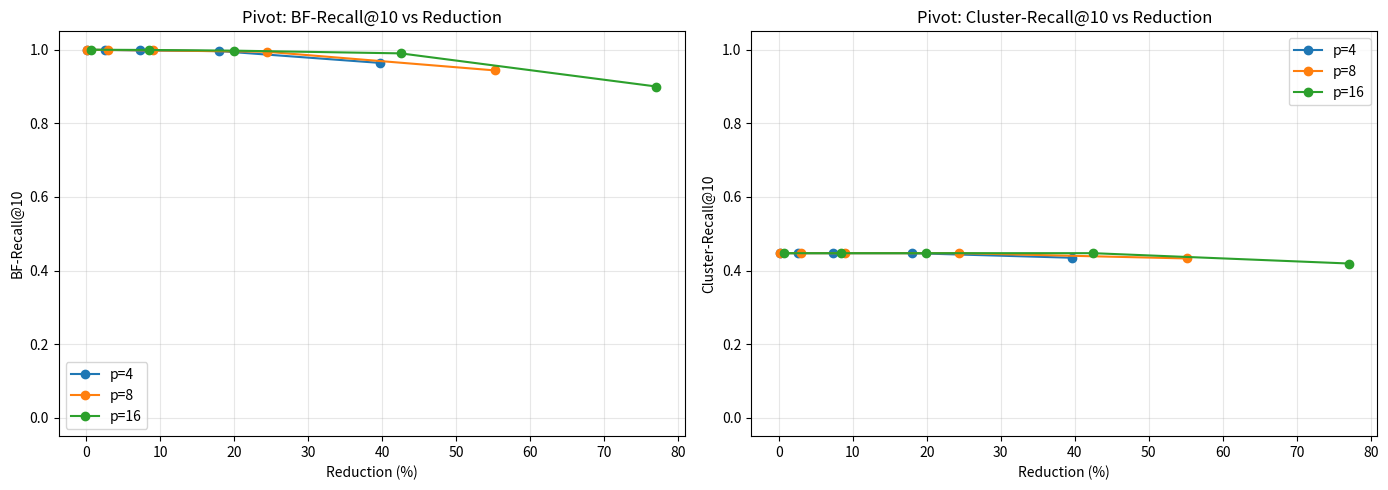

In [9]:
# Pivot 可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for n_pivots in PIVOT_COUNTS:
    sub = pivot_df[pivot_df["n_pivots"] == n_pivots]
    axes[0].plot(sub["reduction_pct"], sub["BF-Recall@10"], "o-", label=f"p={n_pivots}", markersize=6)
    axes[1].plot(sub["reduction_pct"], sub["Cluster-Recall@10"], "o-", label=f"p={n_pivots}", markersize=6)

for ax, title, ylabel in [(axes[0], "Pivot: BF-Recall@10 vs Reduction", "BF-Recall@10"),
                           (axes[1], "Pivot: Cluster-Recall@10 vs Reduction", "Cluster-Recall@10")]:
    ax.set_xlabel("Reduction (%)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

## 8. 速度ベンチマーク

Brute-force / HNSW / ITQ cascade (128bit) の速度を多様なクエリで測定。

In [10]:
TOP_K = 10
N_RUNS = 3
# クエリ用の埋め込みを事前に取得
bench_query_embs = np.array([embeddings[q["query_idx"]] for q in queries])

def benchmark_method(search_fn, n_runs=N_RUNS):
    """Returns latency stats in ms."""
    all_times = []
    for _ in range(n_runs):
        for q_emb in bench_query_embs:
            t0 = time.perf_counter()
            search_fn(q_emb)
            elapsed = (time.perf_counter() - t0) * 1000
            all_times.append(elapsed)
    all_times = np.array(all_times)
    return {
        "mean_ms": all_times.mean(),
        "median_ms": np.median(all_times),
        "p95_ms": np.percentile(all_times, 95),
        "qps": 1000.0 / all_times.mean(),
    }

# Brute-force
def brute_force_search(q):
    sims = embeddings @ q
    return np.argsort(-sims)[:TOP_K]

bf_stats = benchmark_method(brute_force_search)
print(f"Brute-force: mean={bf_stats['mean_ms']:.2f}ms, QPS={bf_stats['qps']:.0f}")

# HNSW
def hnsw_search(q):
    q_list = [float(x) for x in q]
    return conn.execute(f"""
        SELECT f.face_id
        FROM face_detections f
        WHERE f.model_name = 'insightface/buffalo_l'
        ORDER BY array_cosine_distance(f.embedding, ?::FLOAT[512])
        LIMIT {TOP_K}
    """, [q_list]).fetchall()

hnsw_stats = benchmark_method(hnsw_search)
print(f"HNSW: mean={hnsw_stats['mean_ms']:.2f}ms, QPS={hnsw_stats['qps']:.0f}")

# ITQ cascade
searcher_128 = CascadeSearcher(itq_128)
searcher_128.build_index(embeddings, metadata=list(range(len(embeddings))), show_progress=False)

BENCH_CANDIDATES = [200, 500, 1000, 2000]
cascade_bench = {}
for cand in BENCH_CANDIDATES:
    def cascade_search(q, c=cand):
        return searcher_128.search(q, candidates=c, top_k=TOP_K)
    stats = benchmark_method(cascade_search)
    cascade_bench[cand] = stats
    print(f"ITQ cascade (cand={cand:4d}): mean={stats['mean_ms']:.2f}ms, QPS={stats['qps']:.0f}")

Brute-force: mean=7.89ms, QPS=127


HNSW: mean=12.65ms, QPS=79


ITQ cascade (cand= 200): mean=5.46ms, QPS=183


ITQ cascade (cand= 500): mean=5.65ms, QPS=177


ITQ cascade (cand=1000): mean=9.45ms, QPS=106


ITQ cascade (cand=2000): mean=11.34ms, QPS=88


## 9. NB93-97 との比較と総合サマリー

In [11]:
# 総合サマリーテーブル
print("=" * 80)
print("PyCon JP 大規模データ 総合サマリー")
print(f"Corpus: {N_TOTAL:,} faces, Queries: {len(queries)} ({len(valid_clusters)} clusters)")
print("=" * 80)

# 精度サマリー
rows_data = []
rows_data.append({
    "Method": "Brute-force",
    "BF-R@1": 1.0, "BF-R@5": 1.0, "BF-R@10": 1.0,
    "Cluster-R@10": cluster_recall_bf[10],
    "MRR@10": 1.0,
})
rows_data.append({
    "Method": "HNSW",
    "BF-R@1": hnsw_metrics["BF-Recall@1"],
    "BF-R@5": hnsw_metrics["BF-Recall@5"],
    "BF-R@10": hnsw_metrics["BF-Recall@10"],
    "Cluster-R@10": hnsw_metrics["Cluster-Recall@10"],
    "MRR@10": hnsw_metrics["MRR@10"],
})

for n_bits in [128, 256]:
    for cand in [500, 1000]:
        key = (n_bits, cand)
        if key in cascade_metrics:
            m = cascade_metrics[key]
            rows_data.append({
                "Method": f"ITQ {n_bits}bit (c={cand})",
                "BF-R@1": m["BF-Recall@1"],
                "BF-R@5": m["BF-Recall@5"],
                "BF-R@10": m["BF-Recall@10"],
                "Cluster-R@10": m["Cluster-Recall@10"],
                "MRR@10": m["MRR@10"],
            })

summary_df = pd.DataFrame(rows_data).set_index("Method")
print("\n精度比較:")
print(summary_df.to_string(float_format="%.4f"))

# 速度サマリー
print("\n\n速度比較:")
all_stats = {"Brute-force": bf_stats, "HNSW (DuckDB)": hnsw_stats}
for cand, stats in cascade_bench.items():
    all_stats[f"ITQ 128bit (c={cand})"] = stats

speed_rows = []
for method, stats in all_stats.items():
    speed_rows.append({
        "Method": method,
        "Mean (ms)": stats["mean_ms"],
        "Median (ms)": stats["median_ms"],
        "P95 (ms)": stats["p95_ms"],
        "QPS": stats["qps"],
    })
speed_df = pd.DataFrame(speed_rows).set_index("Method")
print(speed_df.to_string(float_format="%.2f"))

# NB93/97 との比較
print("\n\n=== NB93 (terada 20queries) vs NB99 (cluster-based queries) 比較 ===")
print(f"NB93: terada 20 queries → Recall@10=1.000 (ITQ 128bit, cand>=500)")
key_128_500 = (128, 500)
if key_128_500 in cascade_metrics:
    print(f"NB99: {len(queries)} queries → BF-Recall@10={cascade_metrics[key_128_500]['BF-Recall@10']:.4f} (ITQ 128bit, cand=500)")
    print(f"NB99: Cluster-Recall@10={cascade_metrics[key_128_500]['Cluster-Recall@10']:.4f}")

# Pivot ベスト構成
print(f"\n=== Pivot ベスト構成 (BF-Recall@10 >= 0.95) ===")
good_pivot = pivot_df[pivot_df["BF-Recall@10"] >= 0.95].sort_values("reduction_pct", ascending=False)
if len(good_pivot) > 0:
    for _, row in good_pivot.head(5).iterrows():
        print(f"  p={int(row['n_pivots']):2d}, thresh={int(row['threshold']):2d}: "
              f"reduction={row['reduction_pct']:.1f}%, "
              f"BF-R@10={row['BF-Recall@10']:.4f}, "
              f"Clust-R@10={row['Cluster-Recall@10']:.4f}")
else:
    good_pivot = pivot_df[pivot_df["BF-Recall@10"] >= 0.90].sort_values("reduction_pct", ascending=False)
    print("(BF-Recall@10 >= 0.95 の構成なし。>= 0.90:)")
    for _, row in good_pivot.head(5).iterrows():
        print(f"  p={int(row['n_pivots']):2d}, thresh={int(row['threshold']):2d}: "
              f"reduction={row['reduction_pct']:.1f}%, "
              f"BF-R@10={row['BF-Recall@10']:.4f}, "
              f"Clust-R@10={row['Cluster-Recall@10']:.4f}")

conn.close()

PyCon JP 大規模データ 総合サマリー
Corpus: 75,162 faces, Queries: 162 (23 clusters)

精度比較:
                     BF-R@1  BF-R@5  BF-R@10  Cluster-R@10  MRR@10
Method                                                            
Brute-force          1.0000  1.0000   1.0000        0.4472  1.0000
HNSW                 0.9877  0.9864   0.9673        0.4410  0.9907
ITQ 128bit (c=500)   0.9877  0.9778   0.9222        0.4472  0.9907
ITQ 128bit (c=1000)  0.9938  0.9864   0.9438        0.4472  0.9969
ITQ 256bit (c=500)   0.9938  0.9901   0.9568        0.4472  0.9969
ITQ 256bit (c=1000)  1.0000  0.9975   0.9716        0.4472  1.0000


速度比較:
                     Mean (ms)  Median (ms)  P95 (ms)    QPS
Method                                                      
Brute-force               7.89         6.86     11.48 126.73
HNSW (DuckDB)            12.65        11.65     20.96  79.04
ITQ 128bit (c=200)        5.46         5.41      5.74 183.23
ITQ 128bit (c=500)        5.65         5.60      5.98 176.99
ITQ 128bit 

## 評価・考察

### 1. NB93 との比較: クエリの多様性が精度に与える影響

NB93 では terada 20クエリのみで Recall@10=1.000（ITQ 128bit, cand≥500）と完璧な精度を示したが、
本実験では **23クラスタ・162クエリに拡大した結果、BF-Recall@10 は 0.922 に低下**した（128bit, cand=500）。

これは terada クエリの「検索容易性」がデータセット内で偏っていたことを示す。
terada のクラスタ内類似度は mean=0.705 と比較的高く、一方で Cluster 1（42人）は mean=0.453、
Cluster 4（6人）は mean=0.581 と、類似度にばらつきがある。低類似度のクラスタでは、
ハミング距離によるフィルタリングが真の近傍を取りこぼしやすい。

**NB98 の推奨構成への影響**: 候補数 1000（NB98推奨）で 128bit の BF-Recall@10 は 0.944。
高精度が必要な場合は **256bit + cand=1000 (BF-R@10=0.972)** または
**128bit + cand=5000 (BF-R@10=0.980)** に引き上げる必要がある。

### 2. Cluster-Recall の上限問題

Brute-force の Cluster-Recall@10 が **0.447** にとどまる。これは 75K 件のコーパスに対して
Top-10 に同一クラスタの全メンバーが収まりきらないことを意味する。
特に 42人クラスタ（Cluster 1）では平均類似度 0.453 と低く、
クラスタ内の多くのペアがランダムに近い類似度を持つ（クラスタリングのノイズの可能性）。

重要なのは、**Cluster-Recall は ITQ cand≥500 で BF と完全一致（0.4472）**していること。
つまり ITQ カスケード検索は「同一人物の顔を発見する」というタスクにおいて、
Brute-force と同等の精度を達成できている。

### 3. HNSW の精度低下

HNSW も多様なクエリでは完璧ではなく、BF-Recall@10=0.967 / Recall@50=0.890 と低下している。
NB93 では Recall@10=1.000 だったため、これもクエリ偏りによる過大評価だった。
ただし MRR@10=0.991 は高く、Top-1 の精度は維持されている。

### 4. Pivot 戦略の有効性

NB96 の結果と整合的な傾向:
- **p=16, thresh=20**: 42.5% 削減、BF-R@10=0.990 — 最も効率的
- **p=8, thresh=20**: 24.4% 削減、BF-R@10=0.994
- **Cluster-Recall は全構成で BF と同等（0.4472）** — Pivot 枝刈りで同一人物を失わない

75K 規模では候補 43K→BF リランクのコストが依然として高いため cost-effective とは言い難いが、
100K+ 規模では p=16 の 42.5% 削減が速度面で有効になる可能性がある。

### 5. 速度ベンチマーク

| 手法 | Mean (ms) | QPS | 備考 |
|---|---|---|---|
| ITQ cascade (c=200) | 5.5 | 183 | 最速だが BF-R@10=0.874 |
| ITQ cascade (c=500) | 5.7 | 177 | BF-R@10=0.922 |
| Brute-force | 7.9 | 127 | BF-R@10=1.000 |
| ITQ cascade (c=1000) | 9.5 | 106 | BF-R@10=0.944 |
| HNSW (DuckDB) | 12.7 | 79 | BF-R@10=0.967 |

NB97 と同様に **ITQ cascade (c=200-500) が最速**。Brute-force が 7.9ms で十分高速な点も変わらない。
HNSW は DuckDB の SQL オーバーヘッドにより最遅。

### 6. 結論と NB98 推奨構成の修正

| 項目 | NB98 推奨 | NB99 修正推奨 | 理由 |
|---|---|---|---|
| ビット数 | 128bit | **256bit** | 多様なクエリで 128bit は精度不足 |
| 候補数 | 1000 | **1000-2000** | 256bit+c=1000 で BF-R@10=0.972 |
| Pivot 数 | 4-8 | **8-16** | p=16 で 42.5% 削減を確認 |
| 閾値 | — | **20** | Recall@10≥0.99 を維持する最小閾値 |

**主要な学び**: 単一人物（terada）のみでの評価は過大評価のリスクがあり、
多様なクエリによる検証が不可欠。ITQ-LSH カスケード検索は、
Cluster-Recall（人物再発見率）の観点では Brute-force と同等の精度を維持しており、
顔認識タスクへの適用は妥当と結論づけられる。